# Anchored Langevin with a constant skew field

Heavy-tailed target: a $d=3$ Student-t, $\nu = 6$, condition number $\kappa = 100$.

$$q(x) = 1 + \tfrac{1}{\nu}x^{\top}\Sigma^{-1}x,\qquad
  U = \iota\log q,\qquad U_0 = \beta\log q,\qquad \beta = \iota - 1$$

The anchored SDE is $dX = -\nabla U_0(X)\,e^{U-U_0}\,dt + \sqrt{2}\,e^{(U-U_0)/2}dW$.
A constant skew matrix $J_a$ is added to the drift; being skew it leaves the
target invariant.

Two runs: $J = 0$ and $J_a$.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# the skewanchor package lives in the repo root, one level up from notebooks/
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from skewanchor.targets import anisotropic_student_t
from skewanchor import metrics, runner, samplers, skew, skewfield as sf

In [2]:
# ---- parameters ---------------------------------------------------------
D, NU, KAPPA = 3, 6.0, 100.0     # target
A = 4.0                          # field strength: J_a has spectral norm A
N, REPS, STEPS = 5000, 5, 20000  # particles, replications, iterations
RAMP = 10.0                      # warm-up of the skew field, in fast relaxations
PRIOR = "normal10"               # starting ensemble, N(0, 10 I)

# Stepsizes equalise STATIONARY accuracy, so the two runs are compared at the
# same asymptotic error and only their convergence speed differs.  Calibrated
# to 2% stationary covariance bias for J = 0 (see experiments/exp12).
ETA = {"zero": 1.172e-03, "const": 1.003e-03}

In [3]:
target = anisotropic_student_t(D, NU, KAPPA)

J_opt = skew.lnp_optimal(target.Sigma_inv)            # the direction that maximises the gap
J_a = A * J_opt / np.linalg.norm(J_opt, 2)            # scaled to spectral norm A

fields = {"zero": None, "const": sf.ConstantSkew(J_a)}
record_at = runner.log_schedule(STEPS, 90)
print(target)
print(f"\nJ_a (spectral norm {np.linalg.norm(J_a, 2):.2f}):\n{np.round(J_a, 4)}")

LogQuadraticTarget(d=3, nu=6, iota=4.5, beta=3.5, s=1, cond(Sigma)=100)

J_a (spectral norm 4.00):
[[-0.     -0.3866 -2.7034]
 [ 0.3866 -0.     -2.9227]
 [ 2.7034  2.9227 -0.    ]]


In [4]:
def convergence_curve(field, eta):
    """Sliced 2-Wasserstein to the exact target, averaged over replications."""
    curves = []
    for r in range(REPS):
        x = runner.make_prior(PRIOR, D, N, np.random.default_rng(500 + r))
        schedule = samplers.warmup_schedule(target, eta, RAMP) if field is not None else None
        step = samplers.field_anchored_step(target, eta, field, "euler", schedule=schedule)
        rng = np.random.default_rng(9000 + r)
        w, k = [], 0
        for t in record_at:
            while k < t:
                x = step(x, rng)
                k += 1
            w.append(metrics.axis_sliced_w2(x, target))
        curves.append(w)
    return np.mean(curves, axis=0)

curves = {key: convergence_curve(fields[key], ETA[key]) for key in ("zero", "const")}
print("done")

done


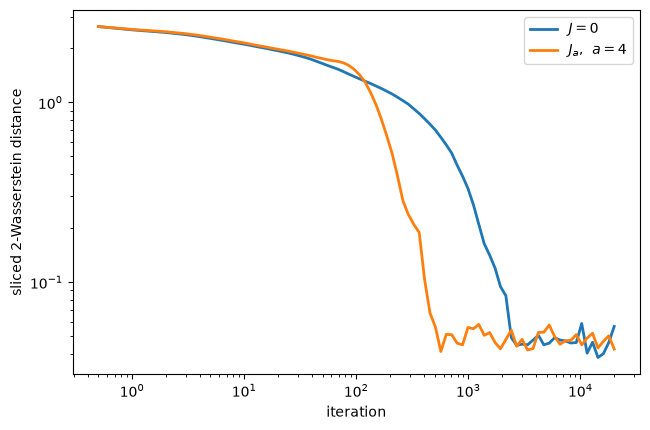

In [5]:
it = np.asarray(record_at, dtype=float)
it[0] = it[1] / 2                       # first point is iteration 0; nudge it onto the log axis

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.plot(it, curves["zero"],  lw=2.0, label=r"$J = 0$")
ax.plot(it, curves["const"], lw=2.0, label=rf"$J_a$,  $a = {A:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("sliced 2-Wasserstein distance")
ax.legend()
fig.tight_layout()
fig.savefig("anchored_constant_field.png", dpi=200)
plt.show()